In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [4]:
df = pd.read_csv('sales_cleaned.csv', encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Make sure derived columns exist
if 'Year' not in df.columns:
    df['Year']       = df['Order Date'].dt.year
if 'Month' not in df.columns:
    df['Month']      = df['Order Date'].dt.month
if 'Month Name' not in df.columns:
    df['Month Name'] = df['Order Date'].dt.month_name()
if 'Quarter' not in df.columns:
    df['Quarter']    = df['Order Date'].dt.quarter

print('Dataset loaded:', df.shape)
print('Date range :', df['Order Date'].min().date(), 'to', df['Order Date'].max().date())

df.head()

Dataset loaded: (9326, 29)
Date range : 2014-01-03 to 2017-12-30


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Discount,Profit,Year,Month,Month Name,Quarter,Day of Week,Profit Margin %,Revenue per Unit,Is Profitable
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.0,41.9136,2016,11,November,4,Tuesday,16.00,130.98,True
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.0,219.5820,2016,11,November,4,Tuesday,30.00,243.98,True
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.0,6.8714,2016,6,June,2,Sunday,47.00,7.31,True
3,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.2,2.5164,2015,10,October,4,Sunday,11.25,11.18,True
4,6,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,0.0,14.1694,2014,6,June,2,Monday,29.00,6.98,True


In [5]:
# ── Aggregate ──────────────────────────────────────────
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = (
    df.groupby('Month Name')
      .agg(Total_Sales=('Sales','sum'), Orders=('Sales','count'))
      .reindex(month_order)
      .reset_index()
)

print('Monthly Sales Summary:')
print(monthly.to_string(index=False))

Monthly Sales Summary:
Month Name  Total_Sales  Orders
   January   39592.5770     353
  February   33939.1394     285
     March   82434.8094     645
     April   73197.6996     631
       May   81322.8637     694
      June   78541.5788     665
      July   87379.2550     671
    August   78838.2390     653
 September  145393.7193    1286
   October   90153.4092     770
  November  176851.7792    1368
  December  162456.2365    1305


In [6]:
# ── Insight Numbers ────────────────────────────────────
best_month  = monthly.loc[monthly['Total_Sales'].idxmax(), 'Month Name']
worst_month = monthly.loc[monthly['Total_Sales'].idxmin(), 'Month Name']
best_val    = monthly['Total_Sales'].max()
worst_val   = monthly['Total_Sales'].min()

print(f'Best month  : {best_month}  (${best_val:,.0f})')
print(f'Worst month : {worst_month} (${worst_val:,.0f})')
print(f'Difference  : ${best_val - worst_val:,.0f}')

Best month  : November  ($176,852)
Worst month : February ($33,939)
Difference  : $142,913


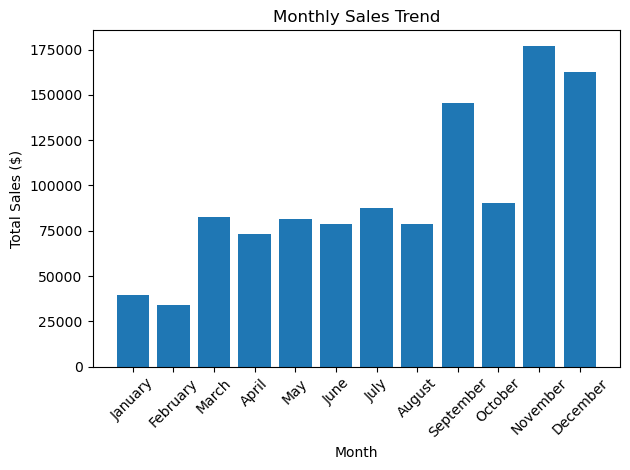

In [ ]:
# ── Plot ───────────────────────────────────────────────
fig, ax = plt.subplots()
ax.bar(monthly['Month Name'], monthly['Total_Sales'])
ax.set_title('Monthly Sales Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('images/01_monthly_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/01_monthly_sales.png')

In [8]:
# ── Aggregate ──────────────────────────────────────────
yearly = (
    df.groupby('Year')
      .agg(Total_Sales=('Sales','sum'),
           Total_Profit=('Profit','sum'),
           Orders=('Sales','count'))
      .reset_index()
)

# Year-over-year growth %
yearly['YoY Growth %'] = yearly['Total_Sales'].pct_change() * 100

print('Yearly Summary:')
print(yearly.to_string(index=False))

Yearly Summary:
 Year  Total_Sales  Total_Profit  Orders  YoY Growth %
 2014  231112.3051    24690.0628    1857           NaN
 2015  246255.7455    28961.5882    1958      6.552416
 2016  288538.0808    29535.8689    2409     17.170091
 2017  364195.1747    38220.2095    3102     26.220835


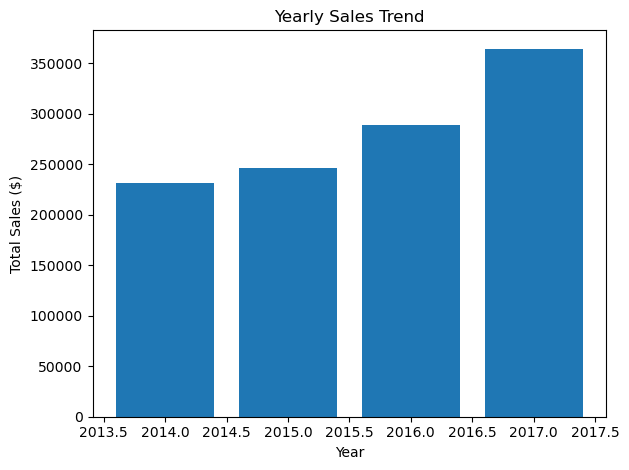

In [ ]:
# ── Plot — dual axis (Sales bar + Profit line) ─────────
fig, ax = plt.subplots()
ax.bar(yearly['Year'], yearly['Total_Sales'])
ax.set_title('Yearly Sales Trend')
ax.set_xlabel('Year')
ax.set_ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('images/02_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/02_yearly_trend.png')

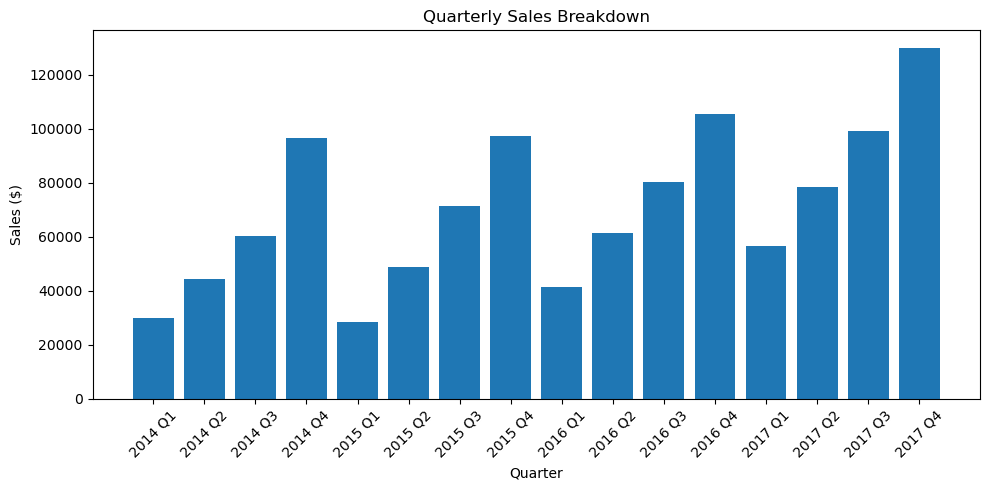

In [ ]:
# ── Quarterly breakdown ────────────────────────────────
quarterly = (
    df.groupby(['Year','Quarter'])['Sales'].sum()
      .reset_index()
)
quarterly['Period'] = quarterly['Year'].astype(str) + ' Q' + quarterly['Quarter'].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(quarterly['Period'], quarterly['Sales'])
ax.set_title('Quarterly Sales Breakdown')
ax.set_xlabel('Quarter')
ax.set_ylabel('Sales ($)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('images/03_quarterly_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/03_quarterly_sales.png')

In [11]:
# ── Aggregate ──────────────────────────────────────────
top_products = (
    df.groupby('Product Name')
      .agg(Total_Sales=('Sales','sum'),
           Total_Profit=('Profit','sum'),
           Orders=('Sales','count'))
      .sort_values('Total_Sales', ascending=False)
      .head(10)
      .reset_index()
)

top_products['Revenue Share %'] = (
    top_products['Total_Sales'] / df['Sales'].sum() * 100
).round(2)

print('Top 10 Products:')
print(top_products[['Product Name','Total_Sales','Total_Profit','Revenue Share %']].to_string(index=False))

Top 10 Products:
                                   Product Name  Total_Sales  Total_Profit  Revenue Share %
         Hon Every-Day Series Multi-Task Chairs     5225.844      112.7880             0.46
             Adjustable Depth Letter/Legal Cart     5008.296     1143.1980             0.44
                     Ki Adjustable-Height Table     4552.641     -248.4822             0.40
              Fellowes Officeware Wire Shelving     4509.466     -332.3710             0.40
Global Wood Trimmed Manager'S Task Chair, Khaki     4166.884     -503.1194             0.37
             Chromcraft Round Conference Tables     4130.673     -275.3782             0.37
               Standard Rollaway File With Lock     4036.256      836.0816             0.36
                Global Ergonomic Managers Chair     4017.756      535.7008             0.36
  Global Airflow Leather Mesh Back Chair, Black     3955.676      573.7240             0.35
                Fellowes High-Stak Drawer Files     3946.656   

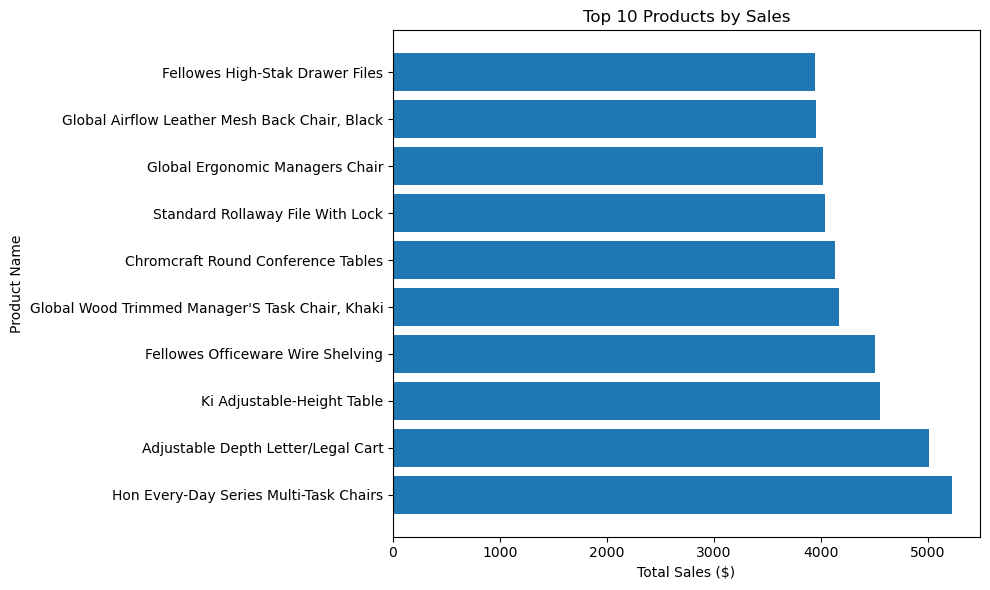

In [ ]:
# ── Plot — horizontal bar ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_products['Product Name'], top_products['Total_Sales'])
ax.set_title('Top 10 Products by Sales')
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('Product Name')
plt.tight_layout()
plt.savefig('images/04_top_products.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/04_top_products.png')

In [13]:
# ── Bottom 10 Products (low performers) ───────────────
bottom_products = (
    df.groupby('Product Name')['Sales'].sum()
      .sort_values(ascending=True)
      .head(10)
      .reset_index()
)
print('Bottom 10 Products by Sales:')
print(bottom_products.to_string(index=False))

Bottom 10 Products by Sales:
                                                    Product Name  Sales
Eureka Disposable Bags For Sanitaire Vibra Groomer I Upright Vac  1.624
                                                         Avery 5  5.760
                                                        Xerox 20  6.480
                                             Grip Seal Envelopes  7.072
              Avery Hi-Liter Pen Style Six-Color Fluorescent Set  7.700
 Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink  7.800
                                                      Xerox 1989  7.968
                                               4009 Highlighters  8.040
                                      Stockwell Gold Paper Clips  8.096
                                                      Newell 308  8.400


In [14]:
# ── Aggregate ──────────────────────────────────────────
region = (
    df.groupby('Region')
      .agg(Total_Sales=('Sales','sum'),
           Total_Profit=('Profit','sum'),
           Orders=('Sales','count'),
           Avg_Order_Value=('Sales','mean'))
      .sort_values('Total_Sales', ascending=False)
      .reset_index()
)

region['Sales Share %'] = (region['Total_Sales'] / region['Total_Sales'].sum() * 100).round(1)

print('Region Summary:')
print(region.to_string(index=False))

Region Summary:
 Region  Total_Sales  Total_Profit  Orders  Avg_Order_Value  Sales Share %
   West  373051.4560    51912.9098    2985       124.975362           33.0
   East  316310.9500    34875.7200    2648       119.452776           28.0
Central  258290.2726     4616.4881    2186       118.156575           22.9
  South  182448.6275    30002.6115    1507       121.067437           16.1


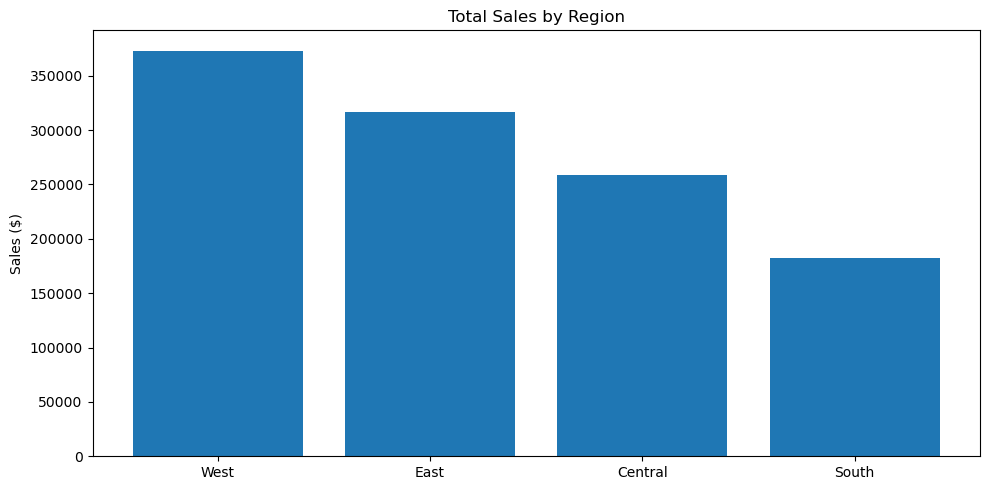

In [ ]:
# ── Plot — side-by-side bar + pie ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(region['Region'], region['Total_Sales'])
ax.set_title('Total Sales by Region')
ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('images/05_region_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/05_region_sales.png')

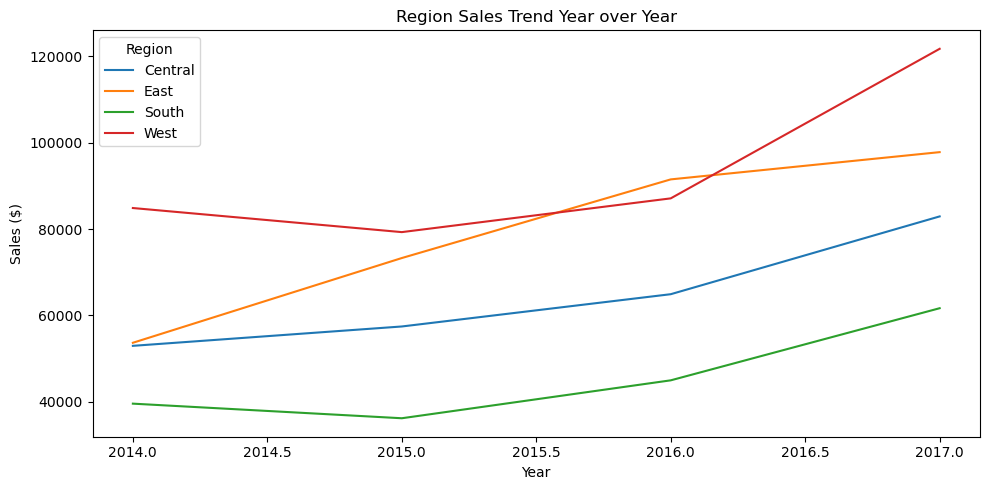

In [ ]:
# ── Region trend over time ─────────────────────────────
region_yearly = (
    df.groupby(['Year','Region'])['Sales'].sum()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for reg in region_yearly['Region'].unique():
    subset = region_yearly[region_yearly['Region'] == reg]
    ax.plot(subset['Year'], subset['Sales'], label=reg)
ax.set_title('Region Sales Trend Year over Year')
ax.set_xlabel('Year')
ax.set_ylabel('Sales ($)')
ax.legend(title='Region')
plt.tight_layout()
plt.savefig('images/06_region_yearly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/06_region_yearly.png')

In [17]:
# ── Aggregate ──────────────────────────────────────────
category = (
    df.groupby('Category')
      .agg(Total_Sales=('Sales','sum'),
           Total_Profit=('Profit','sum'),
           Orders=('Sales','count'))
      .reset_index()
)
category['Profit Margin %'] = (
    category['Total_Profit'] / category['Total_Sales'] * 100
).round(2)

print('Category Profit Analysis:')
print(category.to_string(index=False))

Category Profit Analysis:
       Category  Total_Sales  Total_Profit  Orders  Profit Margin %
      Furniture  375806.9541    -1462.8535    1862            -0.39
Office Supplies  425748.8070    73997.5237    5857            17.38
     Technology  328545.5450    48873.0592    1607            14.88


In [18]:
# ── Sub-category breakdown ─────────────────────────────
sub_cat = (
    df.groupby(['Category','Sub-Category'])
      .agg(Total_Sales=('Sales','sum'),
           Total_Profit=('Profit','sum'))
      .reset_index()
)
sub_cat['Profit Margin %'] = (
    sub_cat['Total_Profit'] / sub_cat['Total_Sales'] * 100
).round(2)
sub_cat = sub_cat.sort_values('Profit Margin %', ascending=False)

print('\nSub-Category Profit Margins:')
print(sub_cat[['Category','Sub-Category','Total_Sales','Profit Margin %']].to_string(index=False))


Sub-Category Profit Margins:
       Category Sub-Category  Total_Sales  Profit Margin %
Office Supplies       Labels   12486.3120            44.42
Office Supplies        Paper   78479.2060            43.39
Office Supplies    Envelopes   16476.4020            42.27
Office Supplies    Fasteners    3024.2800            31.40
     Technology      Copiers   10819.6580            27.74
Office Supplies          Art   26005.7680            24.67
     Technology  Accessories  109065.1760            22.93
      Furniture  Furnishings   81808.6920            13.25
     Technology       Phones  184939.6200            12.86
Office Supplies   Appliances   60278.1410             8.76
Office Supplies      Storage  142152.5960             7.02
Office Supplies      Binders   74989.4780             5.87
      Furniture       Chairs  156644.5120             3.61
Office Supplies     Supplies   11856.6240             3.46
      Furniture    Bookcases   58203.6896            -8.51
     Technology     Machin

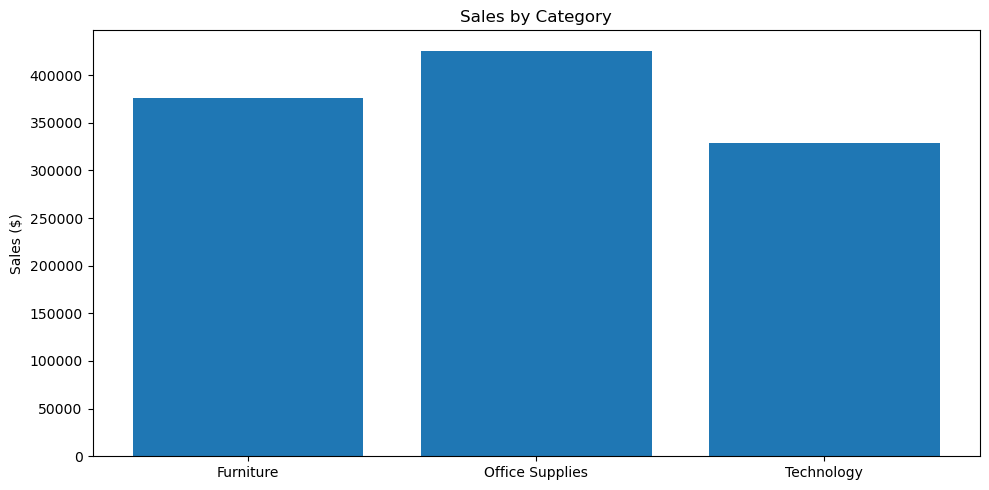

In [ ]:
# ── Plot — 3-panel category view ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(category['Category'], category['Total_Sales'])
ax.set_title('Sales by Category')
ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('images/07_category_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/07_category_profit.png')

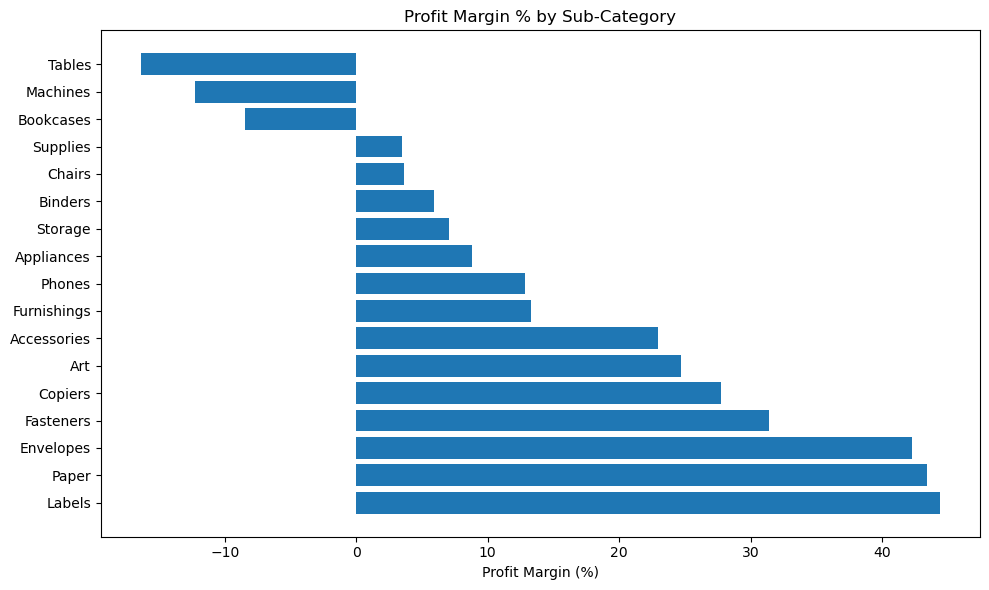

In [21]:
# ── Sub-category profit margin bar ────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(sub_cat['Sub-Category'], sub_cat['Profit Margin %'])
ax.set_title('Profit Margin % by Sub-Category')
ax.set_xlabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

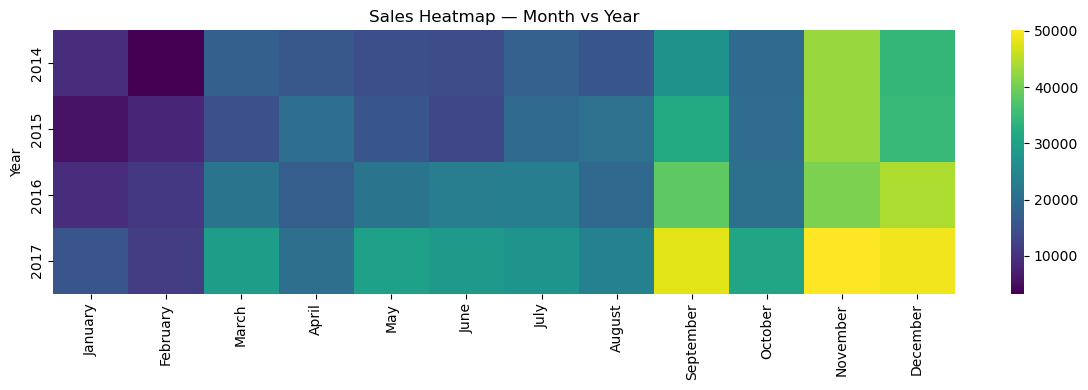

In [22]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

heatmap_data = (
    df.groupby(['Year','Month Name'])['Sales'].sum()
      .reset_index()
      .pivot(index='Year', columns='Month Name', values='Sales')
      .reindex(columns=month_order)
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(heatmap_data, cmap='viridis', ax=ax)
ax.set_title('Sales Heatmap — Month vs Year')
ax.set_xlabel('')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

In [23]:
total_sales      = df['Sales'].sum()
total_profit     = df['Profit'].sum()
overall_margin   = (total_profit / total_sales * 100)
top_region       = df.groupby('Region')['Sales'].sum().idxmax()
top_product      = df.groupby('Product Name')['Sales'].sum().idxmax()
top_category     = df.groupby('Category')['Profit'].sum().idxmax()
best_month_name  = (df.groupby('Month Name')['Sales'].sum()
                      .reindex(month_order).idxmax())

print('=' * 55)
print('         KEY BUSINESS INSIGHTS')
print('=' * 55)
print(f'  Total Revenue      : ${total_sales:,.0f}')
print(f'  Total Profit       : ${total_profit:,.0f}')
print(f'  Overall Margin     : {overall_margin:.1f}%')
print(f'  Best Month         : {best_month_name}')
print(f'  Top Region         : {top_region}')
print(f'  Top Product        : {top_product[:50]}')
print(f'  Most Profitable Cat: {top_category}')
print('=' * 55)
# print('Copy these numbers into your README and resume bullets!')

         KEY BUSINESS INSIGHTS
  Total Revenue      : $1,130,101
  Total Profit       : $121,408
  Overall Margin     : 10.7%
  Best Month         : November
  Top Region         : West
  Top Product        : Hon Every-Day Series Multi-Task Chairs
  Most Profitable Cat: Office Supplies
